In [97]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_validate
import pickle

In [72]:
data = pd.read_csv('parkinsons - parkinsons.csv')

In [73]:
data

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [74]:
data.shape

(195, 24)

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [76]:
data1=data.drop(['name', 'status'], axis=1 )

In [77]:
data1

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0.02745,0.07008,0.02764,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0.01879,0.04812,0.01810,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0.01667,0.03804,0.10715,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0.01588,0.03794,0.07223,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


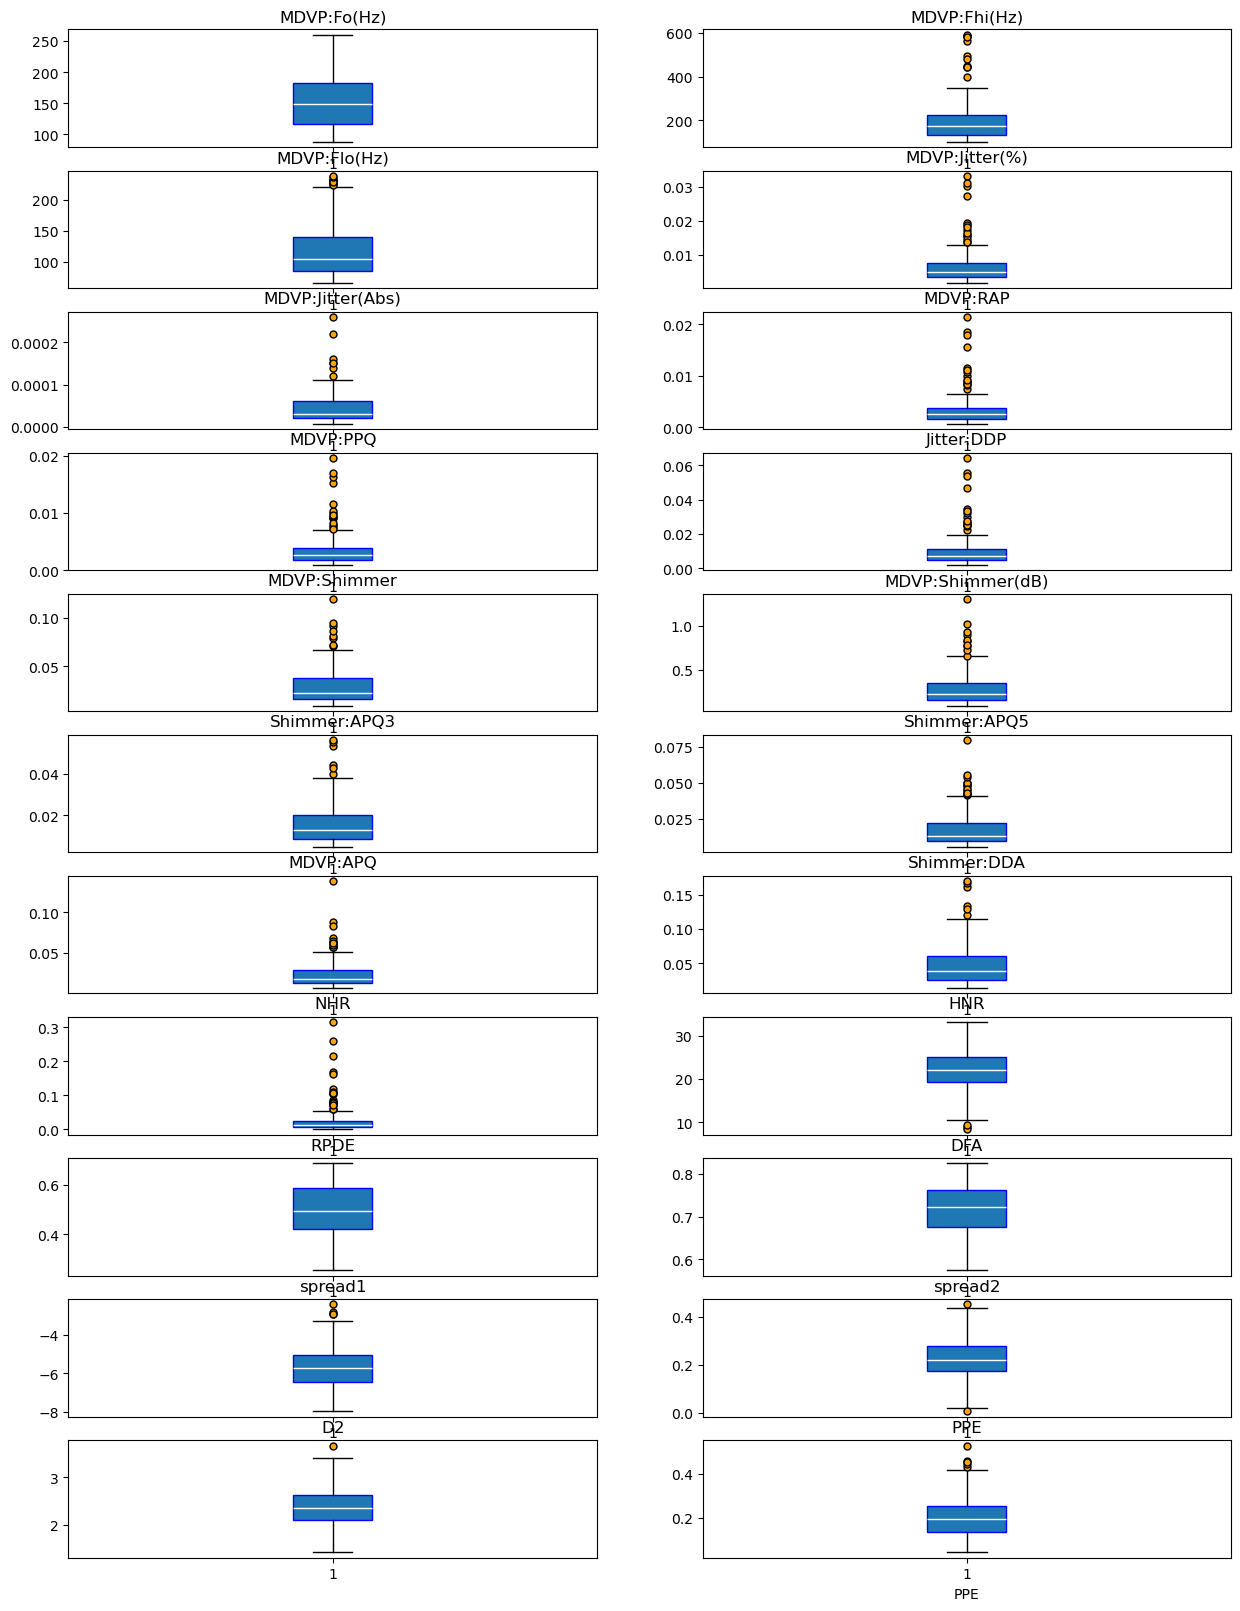

In [78]:
out_col=data1.columns
plotting=len(data1.columns)
plot=2
fix = (plotting+plot-1)//plot
plt.figure(figsize=(15,40))
for i, col in enumerate(out_col, 1):
    plt.subplot(plotting, plot, i)
    plt.boxplot(data1[col], patch_artist=True, boxprops=dict(color='blue'), medianprops=dict(color='white'), whiskerprops=dict(color='black'), capprops=dict(color='black'), flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
    plt.title(col)
plt.xlabel(col)
plt.show()

In [79]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       195 non-null    float64
 1   MDVP:Fhi(Hz)      195 non-null    float64
 2   MDVP:Flo(Hz)      195 non-null    float64
 3   MDVP:Jitter(%)    195 non-null    float64
 4   MDVP:Jitter(Abs)  195 non-null    float64
 5   MDVP:RAP          195 non-null    float64
 6   MDVP:PPQ          195 non-null    float64
 7   Jitter:DDP        195 non-null    float64
 8   MDVP:Shimmer      195 non-null    float64
 9   MDVP:Shimmer(dB)  195 non-null    float64
 10  Shimmer:APQ3      195 non-null    float64
 11  Shimmer:APQ5      195 non-null    float64
 12  MDVP:APQ          195 non-null    float64
 13  Shimmer:DDA       195 non-null    float64
 14  NHR               195 non-null    float64
 15  HNR               195 non-null    float64
 16  RPDE              195 non-null    float64
 1

In [80]:
data2= data1.drop([ 'MDVP:Fo(Hz)', 'RPDE', 'DFA'], axis=1)

In [81]:
control=list(data2.columns)
def outlier(df, coln):
    Q1=df[coln].quantile(0.25)
    Q2=df[coln].quantile(0.75)
    IQR=Q2-Q1
    lower=Q1 - 1.5*IQR
    upper=Q2 + 1.5*IQR
    df[coln]=df[coln].clip(lower=lower, upper=upper)
    return df
for i in control:
    if i in data1:
        data1=outlier(data1, i)
        print(f'{i} in control')
    else:
        print(f'{i} not in control')

MDVP:Fhi(Hz) in control
MDVP:Flo(Hz) in control
MDVP:Jitter(%) in control
MDVP:Jitter(Abs) in control
MDVP:RAP in control
MDVP:PPQ in control
Jitter:DDP in control
MDVP:Shimmer in control
MDVP:Shimmer(dB) in control
Shimmer:APQ3 in control
Shimmer:APQ5 in control
MDVP:APQ in control
Shimmer:DDA in control
NHR in control
HNR in control
spread1 in control
spread2 in control
D2 in control
PPE in control


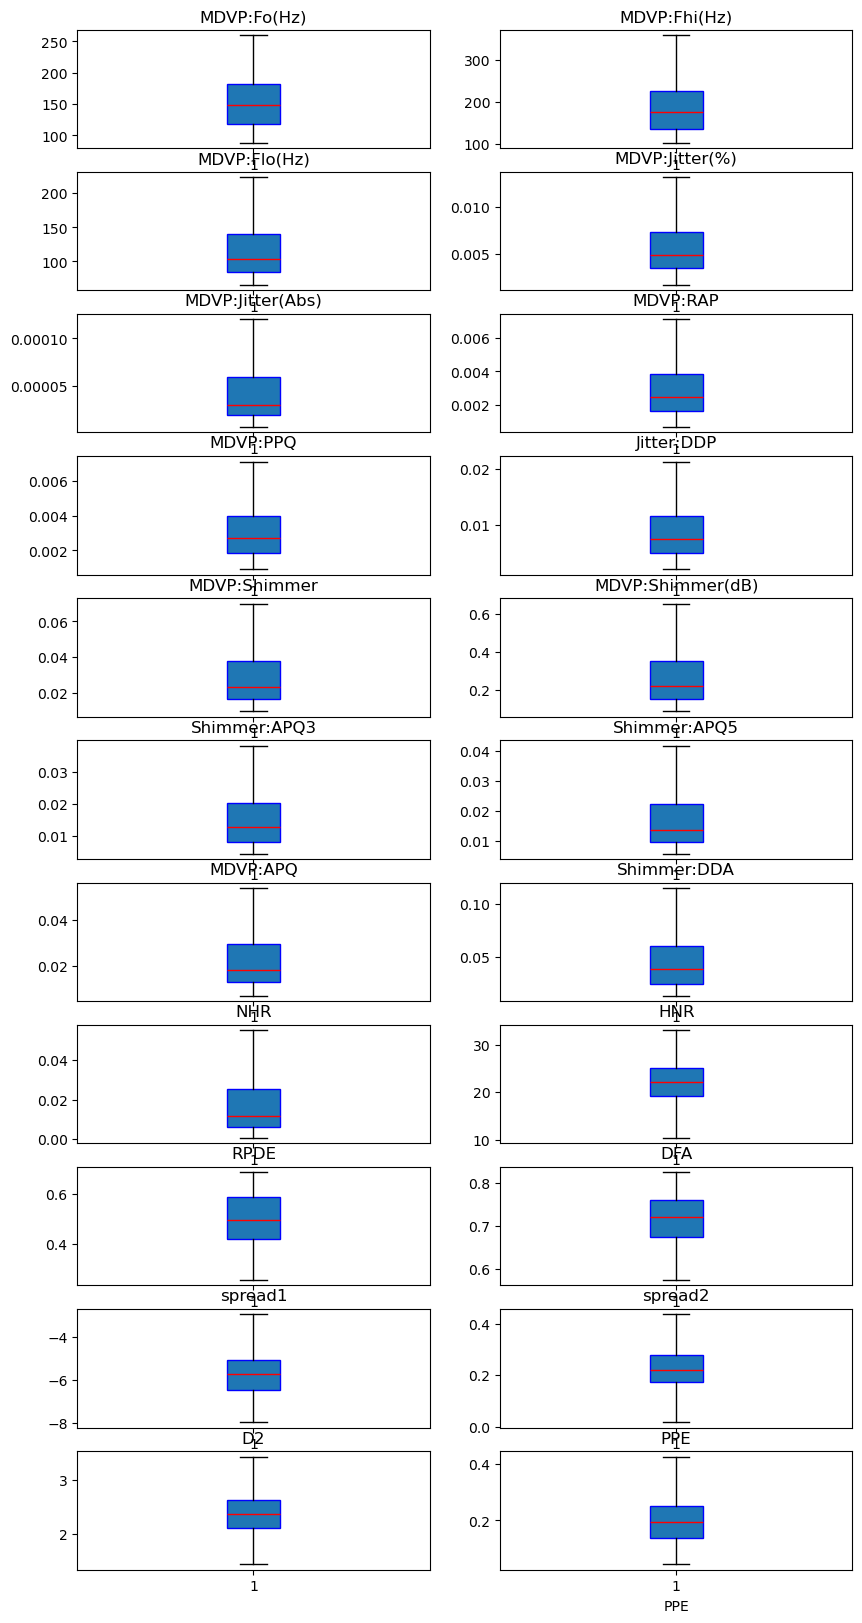

In [82]:
out_col=data1.columns
plot=2
plotting=len(out_col)
con=(plotting+plot-1)//plot
plt.figure(figsize=(10, 20))
for i , col in enumerate(out_col, 1):
    plt.subplot(con, plot, i)
    plt.boxplot(data1[col], patch_artist = True, boxprops=dict(color='blue'), medianprops=dict(color='red'), capprops=dict(color='black'), flierprops=dict(markerfacecolor='orange', marker='o', markersize=5), whiskerprops=dict(color='black'))
    plt.title(col)
plt.xlabel(col)
plt.show()

In [83]:
data1

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.007840,0.00007,0.00370,0.005540,0.01109,0.04374,0.426,...,0.02971,0.06545,0.022110,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.009680,0.00008,0.00465,0.006960,0.01394,0.06134,0.626,...,0.04368,0.09403,0.019290,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.010500,0.00009,0.00544,0.007098,0.01633,0.05233,0.482,...,0.03590,0.08270,0.013090,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.009970,0.00009,0.00502,0.006980,0.01505,0.05492,0.517,...,0.03772,0.08771,0.013530,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.012840,0.00011,0.00655,0.007098,0.01966,0.06425,0.584,...,0.04465,0.10470,0.017670,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.004590,0.00003,0.00263,0.002590,0.00790,0.04087,0.405,...,0.02745,0.07008,0.027640,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.005640,0.00003,0.00331,0.002920,0.00994,0.02751,0.263,...,0.01879,0.04812,0.018100,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.013222,0.00008,0.00624,0.005640,0.01873,0.02308,0.256,...,0.01667,0.03804,0.055212,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,358.220,74.904,0.007400,0.00004,0.00370,0.003900,0.01109,0.02296,0.241,...,0.01588,0.03794,0.055212,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [84]:
SC=StandardScaler()
i=data1.columns
data1[i]=SC.fit_transform(data1[i])

In [85]:
data1

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,-0.829300,-0.500094,-0.964110,0.701875,1.017692,0.440015,1.437914,0.438206,0.885615,0.976347,...,0.518684,0.710297,0.236191,-0.201203,-0.807838,1.760814,0.810831,0.482584,-0.209449,0.906632
1,-0.770972,-0.638805,-0.050885,1.308591,1.382624,0.999991,2.285930,0.998426,1.943849,2.235504,...,1.594294,1.755272,0.063834,-0.648894,-0.387524,1.837562,1.494886,1.316596,0.280817,1.870326
2,-0.909476,-0.919993,-0.104142,1.578975,1.747556,1.465655,2.368044,1.468224,1.402105,1.328911,...,0.995279,1.341012,-0.315105,-0.288994,-0.662075,1.942048,1.153723,1.021926,-0.101522,1.456953
3,-0.909622,-0.811616,-0.108588,1.404215,1.747556,1.218086,2.297874,1.216617,1.557834,1.549263,...,1.135408,1.524193,-0.288212,-0.290603,-0.613134,1.832380,1.455661,1.299181,0.065842,1.873778
4,-0.925657,-0.748930,-0.125313,2.350560,2.477420,2.119942,2.368044,2.122797,2.118818,1.971081,...,1.668978,2.145401,-0.035179,-0.519275,-0.783021,1.909364,1.798426,0.096775,-0.128172,2.348170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.483467,0.681092,-0.510956,-0.369770,-0.442036,-0.190694,-0.323810,-0.188847,0.713050,0.844136,...,0.344677,0.879584,0.574180,-0.549611,-0.483208,-1.090704,-0.788943,-1.261637,0.731971,-0.832238
191,1.339202,1.034426,-0.623233,-0.023547,-0.442036,0.210131,-0.126735,0.212153,-0.090246,-0.049866,...,-0.322092,0.076657,-0.008898,-0.634645,-0.644916,-0.631503,-0.470704,-1.172924,1.067349,-0.421103
192,0.495578,0.825815,-0.980812,2.476684,1.382624,1.937213,1.497633,1.939988,-0.356608,-0.093936,...,-0.485320,-0.291900,2.259390,-0.925138,-0.877441,-1.130853,-1.019432,-0.821135,0.790926,-0.847401
193,1.078761,2.721059,-0.966298,0.556790,-0.077104,0.440015,0.458515,0.438206,-0.363824,-0.188373,...,-0.546146,-0.295556,2.259390,-0.663832,-0.456374,-1.343323,-0.979919,-0.229779,-0.640013,-0.944000


In [86]:
X=data1
Y=data['status']

In [87]:
Y.value_counts()

status
1    147
0     48
Name: count, dtype: int64

In [88]:
smote=SMOTE(random_state=42)
x_resampled, y_resampled= smote.fit_resample(X, Y)

In [89]:
x_resampled = pd.DataFrame(x_resampled, columns=X.columns)
y_resampled = pd.Series(y_resampled, name='status')

In [90]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [91]:
SC = StandardScaler()
x_train = SC.fit_transform(x_train)
x_test = SC.transform(x_test)

In [92]:
cop_par = x_resampled.copy()
cop_par['status']=y_resampled
cop_par.to_csv('parkinson_resample.csv', index=False)

In [93]:
df_park=pd.read_csv('parkinson_resample.csv')
print(df_park['status'].value_counts())

status
1    147
0    147
Name: count, dtype: int64


In [94]:
RFC = RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(x_train, y_train)
y_pred=RFC.predict(x_test)

In [95]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f'accuracy_score : {accuracy_score(y_test, y_pred)}')

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.97      0.98        29

    accuracy                           0.98        59
   macro avg       0.98      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59

[[30  0]
 [ 1 28]]
accuracy_score : 0.9830508474576272


In [98]:
pickle.dump(RFC, open('parkinson_pred.pkl', 'wb'))